In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

In [2]:
seed = 42

root_path = "/home/stefan/ioai-prep/kits/dataset-de4ac44c-311a-4144-a665-3e5e727fe0a9"

# Data

In [3]:
df = pd.read_csv(f"{root_path}/train.csv")
df_train = df.drop(["SampleID", "energy_output"], axis=1)
y = df["energy_output"]

(array([ 6., 15., 13.,  7.,  8.,  6., 11., 13., 17., 11., 16., 12., 14.,
         8.,  3.,  7.,  2.,  4.,  7.,  4.,  4.,  5.,  2.,  0.,  3.,  0.,
         0.,  1.,  0.,  1.]),
 array([  0.22      ,   4.66066667,   9.10133333,  13.542     ,
         17.98266667,  22.42333333,  26.864     ,  31.30466667,
         35.74533333,  40.186     ,  44.62666667,  49.06733333,
         53.508     ,  57.94866667,  62.38933333,  66.83      ,
         71.27066667,  75.71133333,  80.152     ,  84.59266667,
         89.03333333,  93.474     ,  97.91466667, 102.35533333,
        106.796     , 111.23666667, 115.67733333, 120.118     ,
        124.55866667, 128.99933333, 133.44      ]),
 <BarContainer object of 30 artists>)

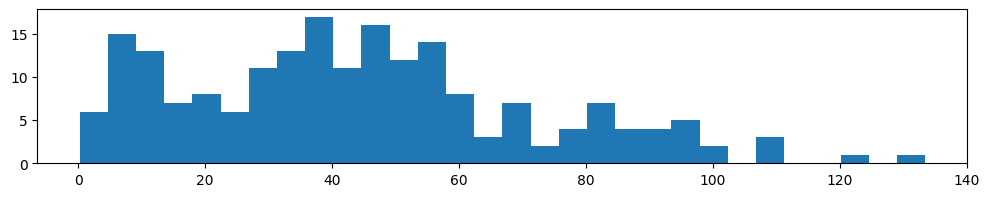

In [4]:
plt.figure(figsize=(12, 2))
plt.hist(y, bins=30)

# Model

In [5]:
X_train, X_test, y_train, y_test = train_test_split(df_train, y, test_size=0.2, random_state=seed)

In [6]:
def evaluate(model):
    cv = cross_val_score(
        model, X_train, y_train, scoring="neg_root_mean_squared_error", cv=3, n_jobs=-1
    )
    cv_score = -(cv.mean() - cv.std())

    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    score = root_mean_squared_error(y_test, preds)

    return cv_score, score

In [7]:
lr = Pipeline(steps=[("scaler", StandardScaler()), ("model", LinearRegression())])
evaluate(lr)

(np.float64(9.714340572911954), 10.152795056836228)

In [8]:
xgb = XGBRegressor(random_state=seed, n_jobs=-1)
evaluate(xgb)

(np.float64(10.1495717046468), 12.130666211585993)

In [9]:
model = xgb
model.fit(df_train, y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=-1, num_parallel_tree=None, ...)

# Submission

In [10]:
df_test = pd.read_csv(f"{root_path}/test.csv")
submission = df_test[["SampleID"]]

df_test = df_test.drop(["SampleID"], axis=1)

In [11]:
submission["energy_output"] = model.predict(df_test).round(2)
submission.head()

,SampleID,energy_output
0,1,57.150002
1,2,48.529999
2,3,53.830002
3,4,77.489998
4,5,87.720001


In [12]:
submission.to_csv(f"{root_path}/submission.csv", index=False)